# 3. Evaluating models' performance

## Somermeyer datasets

In [ ]:
from src.analysis import compute_result_table
from src.paths import data_dir, interm_tables_dir

results = compute_result_table(data_dir, interm_tables_dir, "somermeyer")

In [ ]:
from src.models.linear_regression import linear_regression

results = linear_regression(results, data_dir, interm_tables_dir, "somermeyer")

In [ ]:
from src.models.mlp import mlp

final_results = mlp(results, data_dir, interm_tables_dir, "somermeyer")
output_dir = interm_tables_dir / "models_evaluation" 
output_dir.mkdir(parents=True, exist_ok=True)
final_results.to_csv(output_dir / "somermeyer_all_models.csv", index=True)

In [ ]:
from src.analysis import select_best_models

select_best_models(interm_tables_dir / "models_evaluation", "somermeyer")

In [ ]:
from src.plotting import combined_plot_somermeyer
from src.paths import interm_tables_dir, main_figures_dir

combined_plot_somermeyer(interm_tables_dir / "models_evaluation", main_figures_dir)

In [1]:
from src.paths import data_dir, interm_tables_dir, main_figures_dir
from src.analysis import combined_plot_somermeyer_with_whiskers

combined_plot_somermeyer_with_whiskers(
    models_eval_dir = interm_tables_dir / "models_evaluation",  # has somermeyer_best_models.csv
    output_dir      = main_figures_dir,                         # where figures go
    model_dir       = data_dir,                                 # raw model predictions in data_dir/somermeyer
    epi_dir         = interm_tables_dir,                        # epistasis CSVs for somermeyer
    seeds           = (0,1,2,3,4),                              # change as you like
)

In [1]:
from src.analysis import somermeyer_top_models
from src.paths import interm_tables_dir, main_tables_dir

somermeyer_top_models(interm_tables_dir / "models_evaluation", main_tables_dir)

## Tsuboyama datasets

In [ ]:
from src.analysis import compute_result_table
from src.paths import data_dir, interm_tables_dir

results, counts = compute_result_table(data_dir, interm_tables_dir / "tsuboyama_epistatic", "tsuboyama")
counts.to_csv(interm_tables_dir / "counts.csv", index=True)

In [ ]:
from src.models.linear_regression import linear_regression

results = linear_regression(results, data_dir, interm_tables_dir / "tsuboyama_epistatic", "tsuboyama")

In [ ]:
from src.models.mlp import mlp

final_results = mlp(results, data_dir, interm_tables_dir / "tsuboyama_epistatic", "tsuboyama")
final_results.dropna(axis=1, how="all", inplace=True)
output_dir = interm_tables_dir / "models_evaluation" 
final_results.to_csv(output_dir / "tsuboyama_all_models.csv", index=True)

In [ ]:
from src.analysis import select_best_models

select_best_models(interm_tables_dir / "models_evaluation", "tsuboyama")

In [ ]:
from src.plotting import combined_plot_tsuboyama
from src.paths import main_figures_dir, interm_tables_dir

combined_plot_tsuboyama(interm_tables_dir, main_figures_dir)

In [ ]:
from src.paths import data_dir, interm_tables_dir, supp_figures_dir
from src.analysis import build_tsuboyama_N_series

build_tsuboyama_N_series(
    raw_tsuboyama_dir = interm_tables_dir / "tsuboyama_epistatic",
    model_root_dir    = data_dir,
    work_root_dir     = interm_tables_dir,
    figures_dir       = supp_figures_dir,
)


In [1]:
from src.paths import interm_tables_dir, supp_tables_dir
from src.analysis import tsuboyama_top_models

tsuboyama_top_models(interm_tables_dir, supp_tables_dir)

In [ ]:
from src.plotting import individual_combined_plot_tsuboyama
from src.paths import interm_tables_dir, main_figures_dir

individual_combined_plot_tsuboyama(interm_tables_dir, main_figures_dir)

In [1]:
from src.analysis import combined_plot_tsuboyama_with_whiskers
from src.paths import interm_tables_dir, main_figures_dir, data_dir

combined_plot_tsuboyama_with_whiskers(interm_tables_dir,
                                      main_figures_dir,
                                      data_dir,
                                      interm_tables_dir / "tsuboyama_epistatic")

In [1]:
from src.paths import interm_tables_dir, main_tables_dir
from src.analysis import tsuboyama_top_models_by_seq

tsuboyama_top_models_by_seq(interm_tables_dir, main_tables_dir)

In [1]:
from src.plotting import tsuboyama_epi_distribution_plots
from src.paths import interm_tables_dir, supp_figures_dir

tsuboyama_epi_distribution_plots(interm_tables_dir / "tsuboyama_epistatic", supp_figures_dir / "5_tsuboyama_epi_distribution", fit="kde")

In [2]:
from src.plotting import plot_epi_hist_gt400_onepage, plot_epi_hist_200to400_onepage, plot_epi_hist_100to200_onepage
from src.paths import interm_tables_dir, supp_figures_dir

plot_epi_hist_gt400_onepage(
    input_dir=interm_tables_dir / "tsuboyama_epistatic",
    out_png=supp_figures_dir / "epi_400_kde.png",
    fit="kde",    # или "gaussian", или None
    hist=True,
    bins=70
)

plot_epi_hist_200to400_onepage(
    input_dir=interm_tables_dir / "tsuboyama_epistatic",
    out_png=supp_figures_dir / "epi_200_400_kde.png",
    fit="kde",
    hist=True,
    bins=70
)

Saved: /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/epi_400_kde.png (6 panels)
Saved: /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/epi_200_400_kde.png (5 panels)


In [1]:
from src.plotting import plot_epi_hist_gt400_onepage, plot_epi_hist_200to400_onepage, plot_epi_hist_100to200_onepage
from src.paths import interm_tables_dir, supp_figures_dir

plot_epi_hist_gt400_onepage(
    input_dir=interm_tables_dir / "tsuboyama_epistatic",
    out_png=supp_figures_dir / "epi_400_counts.png",
    hist=True,
    density=False,
    bins=70
)

plot_epi_hist_200to400_onepage(
    input_dir=interm_tables_dir / "tsuboyama_epistatic",
    out_png=supp_figures_dir / "epi_200_400_counts.png",
    hist=True,
    density=False,
    bins=70
)

Saved: /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/epi_400_counts.png (6 panels)
Saved: /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/epi_200_400_counts.png (5 panels)


In [1]:
from src.paths import data_dir, supp_figures_dir, interm_tables_dir
from src.analysis import combined_plot_tsuboyama_top50


combined_plot_tsuboyama_top50(
    model_root_dir=data_dir,
    epi_dir=interm_tables_dir / "tsuboyama_epistatic",
    dataset_name="MYO3_YEAST_Tsuboyama_2023_2BTT",
    models_eval_dir=interm_tables_dir / "models_evaluation",
    output_dir=supp_figures_dir
)

[OK] saved /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/6_combined_plot_MYO3_YEAST_2BTT_top50_whiskers.png


In [2]:
from src.paths import data_dir, supp_figures_dir, interm_tables_dir
from src.analysis import combined_plot_tsuboyama_top50


combined_plot_tsuboyama_top50(
    model_root_dir=data_dir,
    epi_dir=interm_tables_dir / "tsuboyama_epistatic",
    dataset_name="POLG_PESV_Tsuboyama_2023_2MXD",
    models_eval_dir=interm_tables_dir / "models_evaluation",
    output_dir=supp_figures_dir
)

[OK] saved /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/6_combined_plot_POLG_PESV_2MXD_top50_whiskers.png


? Why did results become better after choosing top 50 sequences? 

For example, ESM3: 0.5 <-> 0.7

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/tables/intermediate/tsuboyama_epistatic/POLG_PESV_Tsuboyama_2023_2MXD.csv", index_col=0)
doubles = df[df["num_mutations"] == 2]
epistatic = doubles[doubles["epistatic"] == True]
epi_top_50 = epistatic.nlargest(50, "thermodynamic_coupling")
non_epistatic = doubles[doubles["epistatic"] == False]

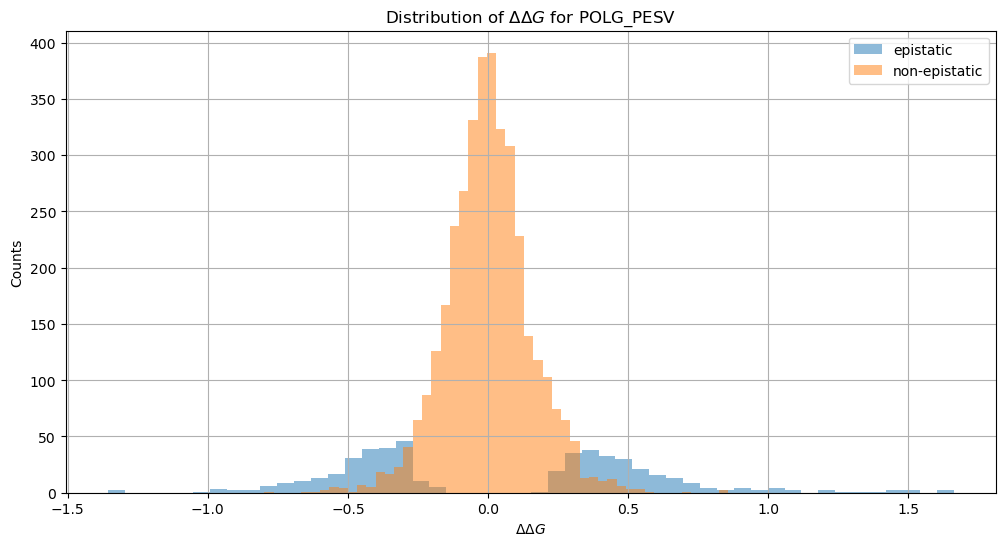

In [15]:
plt.figure(figsize=(12,6))
plt.hist(epistatic["thermodynamic_coupling"], bins=50, alpha=0.5, label="epistatic", density=False)
plt.hist(non_epistatic["thermodynamic_coupling"], bins=50, alpha=0.5, label="non-epistatic", density=False)
plt.xlabel("$\Delta \Delta G$")
plt.ylabel("Counts")
plt.title("Distribution of $\Delta \Delta G$ for POLG_PESV")
plt.grid(True)
plt.legend()

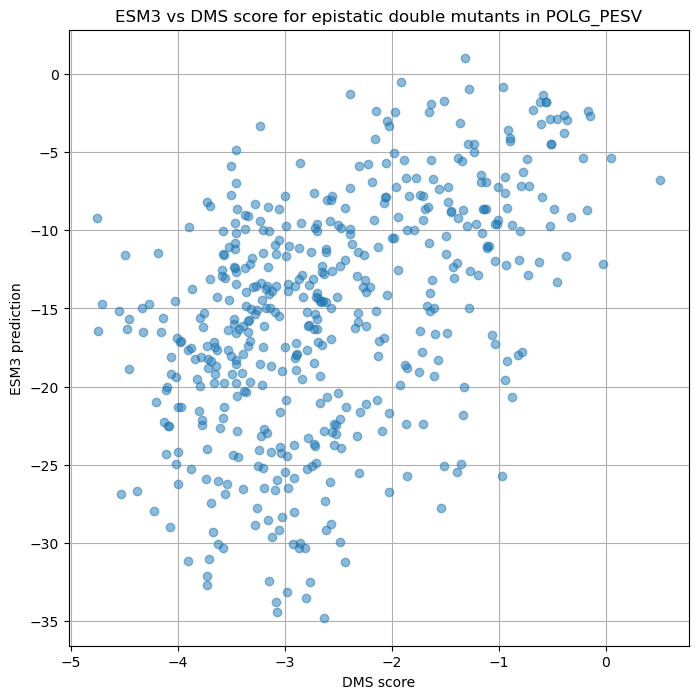

In [19]:
plt.figure(figsize=(8,8))
plt.plot(epistatic["DMS_score"], epistatic["ESM3"], 'o', alpha=0.5)
plt.xlabel("DMS score")
plt.ylabel("ESM3 prediction")
plt.title("ESM3 vs DMS score for epistatic double mutants in POLG_PESV")
plt.grid(True)
plt.show()

In [16]:
epistatic

,mutant,mutated_sequence,DMS_score,DMS_score_bin,Site_Independent,EVmutation,DeepSequence_single,DeepSequence_ensemble,EVE_single,EVE_ensemble,...,deltaG_95CI_low,deltaG_95CI_high,pair_name,recon_dg,thermodynamic_coupling,epistatic,symmetric_1,symmetric_2,symmetric_double,dG_std
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
159,D16E:R52K,ALRDDEYDEWQDIIREWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-0.560171,1,-0.678768,-7.639312,-11.162216,-11.679633,-3.922821,-8.464128,...,3.278426,3.411264,2MXD.pdb_hnet1_4x_|D16X|R52Z,3.033686,0.315048,True,False,True,False,0.033887
183,D16E:W48R,ALRDDEYDEWQDIIREWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-2.051122,0,-0.882147,-10.542089,-9.229454,-9.959612,-7.701195,-8.896361,...,1.780661,1.972775,2MXD.pdb_hnet1_4x_|D16X|W48Z,1.224998,0.632785,True,False,False,False,0.049009
209,D16F:W48E,ALRDDEYDEWQDIIRFWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-2.606982,0,-7.959321,-15.493135,-18.056702,-18.710516,-13.970947,-15.179222,...,1.275804,1.349219,2MXD.pdb_hnet1_4x_|D16X|W48Z,1.609974,-0.308051,True,False,True,False,0.018728
210,D16F:W48F,ALRDDEYDEWQDIIRFWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-0.360298,1,-4.689700,-12.846799,-15.152954,-15.326532,-12.721786,-12.790138,...,3.517279,3.586777,2MXD.pdb_hnet1_4x_|D16X|W48Z,3.061350,0.487257,True,False,False,False,0.017729
224,D16F:W48Y,ALRDDEYDEWQDIIRFWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-0.585509,1,-4.961678,-13.396437,-15.277863,-16.110416,-12.944366,-13.287166,...,3.288562,3.360387,2MXD.pdb_hnet1_4x_|D16X|W48Z,3.075463,0.247933,True,False,False,True,0.018323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5015,W48R:R52W,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-2.657793,0,-13.602209,-15.225747,-16.797760,-18.246844,-11.845322,-13.735597,...,1.183887,1.306710,2MXD.pdb_hnet1_4x_|W48X|R52Z,1.682120,-0.431008,True,False,False,False,0.031332
5076,W48Y:R52D,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-3.229462,0,-11.391299,-14.361610,-15.434799,-17.912296,-12.809418,-14.093294,...,0.600340,0.762276,2MXD.pdb_hnet1_4x_|W48X|R52Z,1.059207,-0.379764,True,False,False,True,0.041310
5080,W48Y:R52H,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-2.145404,0,-11.391299,-14.361610,-15.511185,-17.933405,-12.852051,-11.693275,...,1.714108,1.817448,2MXD.pdb_hnet1_4x_|W48X|R52Z,1.405888,0.357613,True,False,False,True,0.026362


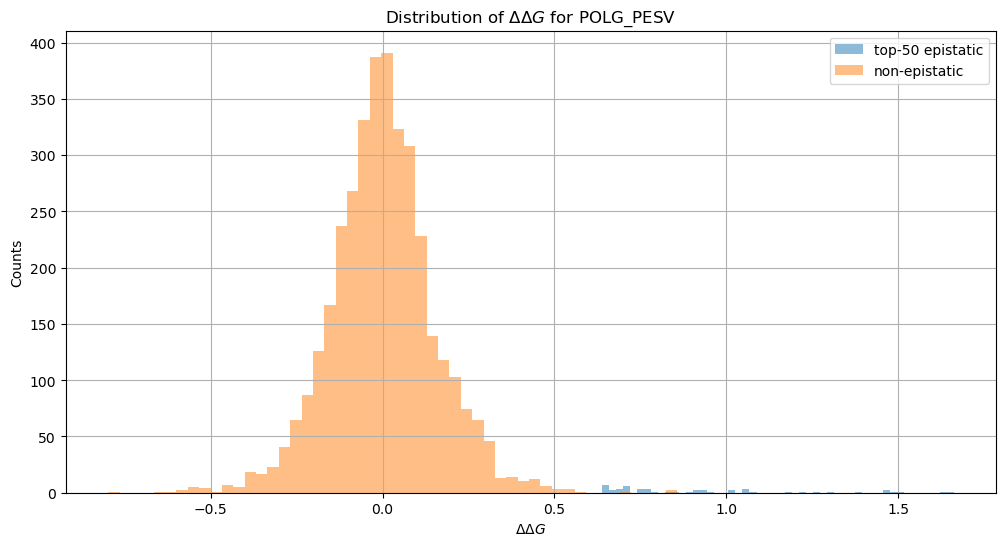

In [24]:
plt.figure(figsize=(12,6))
plt.hist(epi_top_50["thermodynamic_coupling"], bins=50, alpha=0.5, label="top-50 epistatic", density=False)
plt.hist(non_epistatic["thermodynamic_coupling"], bins=50, alpha=0.5, label="non-epistatic", density=False)
plt.xlabel("$\Delta \Delta G$")
plt.ylabel("Counts")
plt.title("Distribution of $\Delta \Delta G$ for POLG_PESV")
plt.grid(True)
plt.legend()


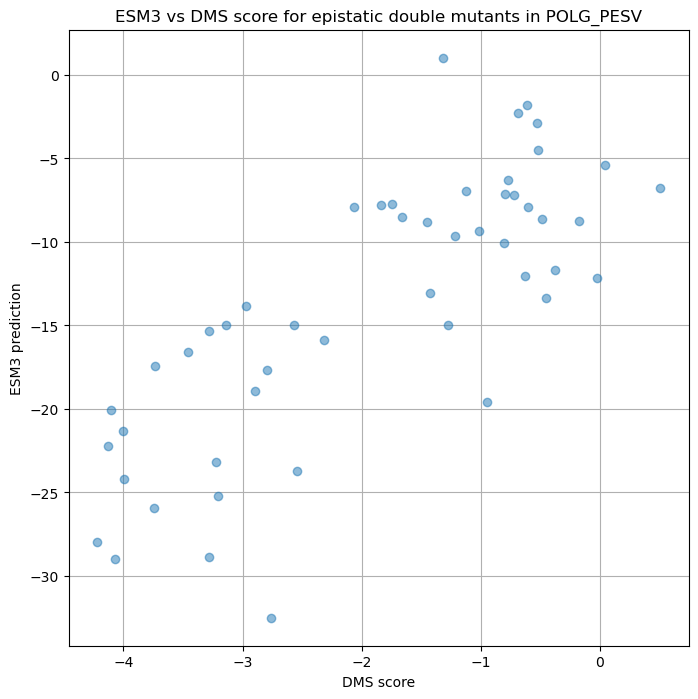

In [25]:
plt.figure(figsize=(8,8))
plt.plot(epi_top_50["DMS_score"], epi_top_50["ESM3"], 'o', alpha=0.5)
plt.xlabel("DMS score")
plt.ylabel("ESM3 prediction")
plt.title("ESM3 vs DMS score for epistatic double mutants in POLG_PESV")
plt.grid(True)
plt.show()

In [29]:
from scipy.stats import spearmanr

print(spearmanr(epistatic["DMS_score"], epistatic["ESM3"])[0])
print(spearmanr(epi_top_50["DMS_score"], epi_top_50["ESM3"])[0])

0.47395198267965466
0.757406962785114


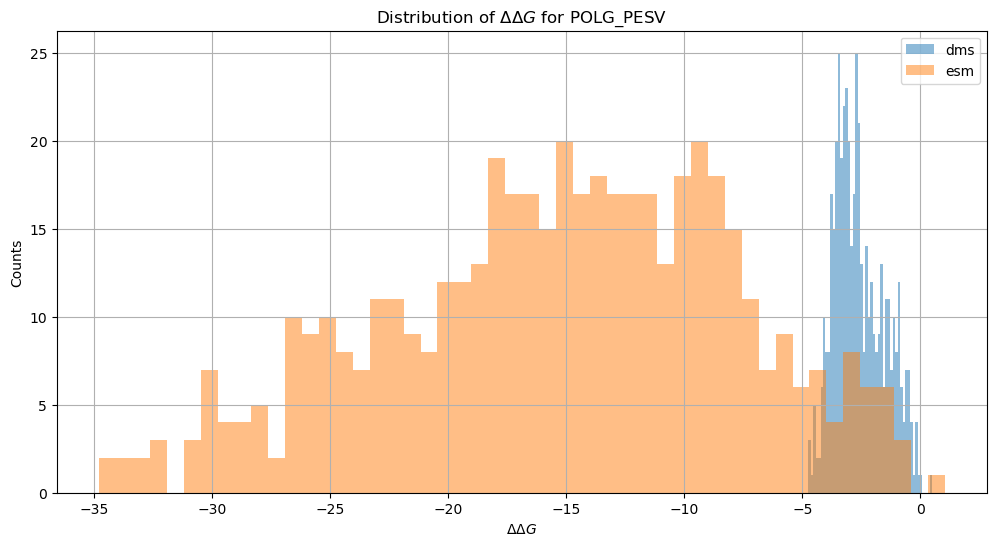

In [30]:
plt.figure(figsize=(12,6))
plt.hist(epistatic["DMS_score"], bins=50, alpha=0.5, label="dms", density=False)
plt.hist(epistatic["ESM3"], bins=50, alpha=0.5, label="esm", density=False)
plt.xlabel("$\Delta \Delta G$")
plt.ylabel("Counts")
plt.title("Distribution of $\Delta \Delta G$ for POLG_PESV")
plt.grid(True)
plt.legend()

# SKSKKSKSKSK

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/tables/intermediate/tsuboyama_epistatic/EPHB2_HUMAN_Tsuboyama_2023_1F0M.csv", index_col=0)
doubles = df[df["num_mutations"] == 2]
epistatic = doubles[doubles["epistatic"] == True]
epi_top_50 = epistatic.nlargest(50, "thermodynamic_coupling")
non_epistatic = doubles[doubles["epistatic"] == False]

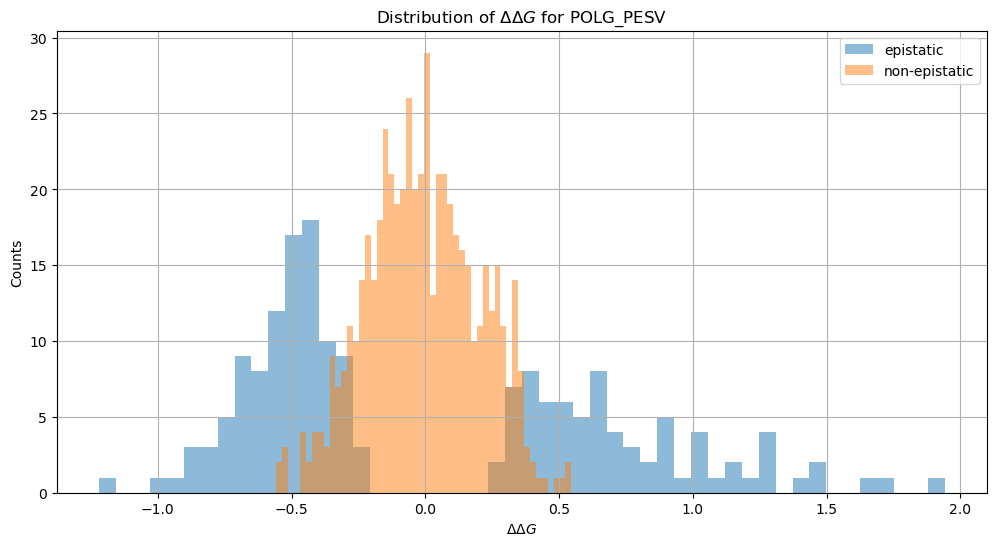

In [33]:
plt.figure(figsize=(12,6))
plt.hist(epistatic["thermodynamic_coupling"], bins=50, alpha=0.5, label="epistatic", density=False)
plt.hist(non_epistatic["thermodynamic_coupling"], bins=50, alpha=0.5, label="non-epistatic", density=False)
plt.xlabel("$\Delta \Delta G$")
plt.ylabel("Counts")
plt.title("Distribution of $\Delta \Delta G$ for POLG_PESV")
plt.grid(True)
plt.legend()

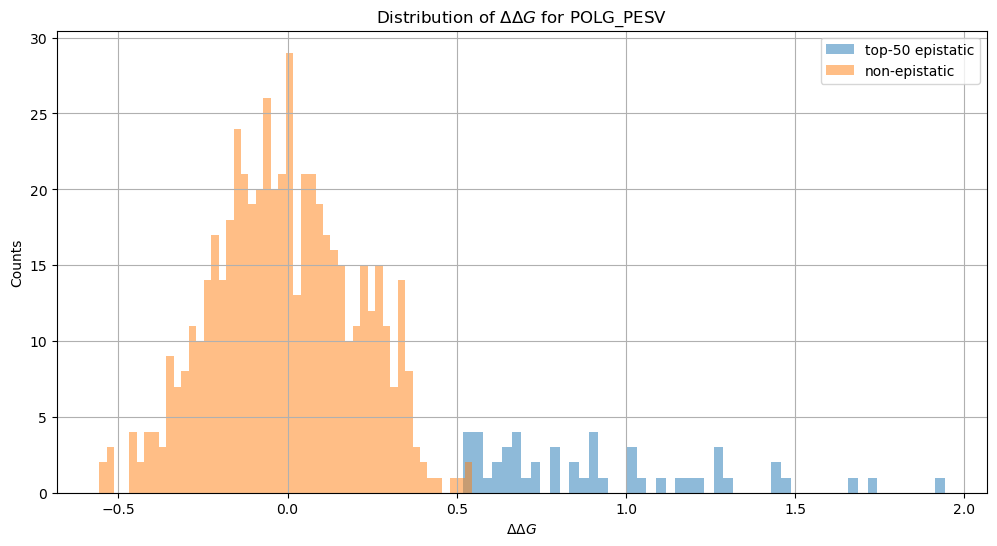

In [32]:
plt.figure(figsize=(12,6))
plt.hist(epi_top_50["thermodynamic_coupling"], bins=50, alpha=0.5, label="top-50 epistatic", density=False)
plt.hist(non_epistatic["thermodynamic_coupling"], bins=50, alpha=0.5, label="non-epistatic", density=False)
plt.xlabel("$\Delta \Delta G$")
plt.ylabel("Counts")
plt.title("Distribution of $\Delta \Delta G$ for POLG_PESV")
plt.grid(True)
plt.legend()


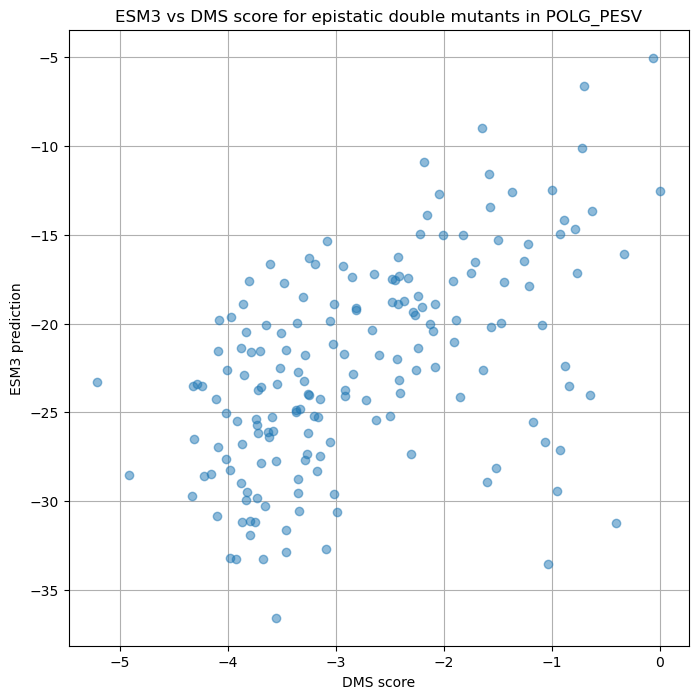

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(epistatic["DMS_score"], epistatic["ESM3"], 'o', alpha=0.5)
plt.xlabel("DMS score")
plt.ylabel("ESM3 prediction")
plt.title("ESM3 vs DMS score for epistatic double mutants in EPHB2_HUMAN")
plt.grid(True)
plt.show()

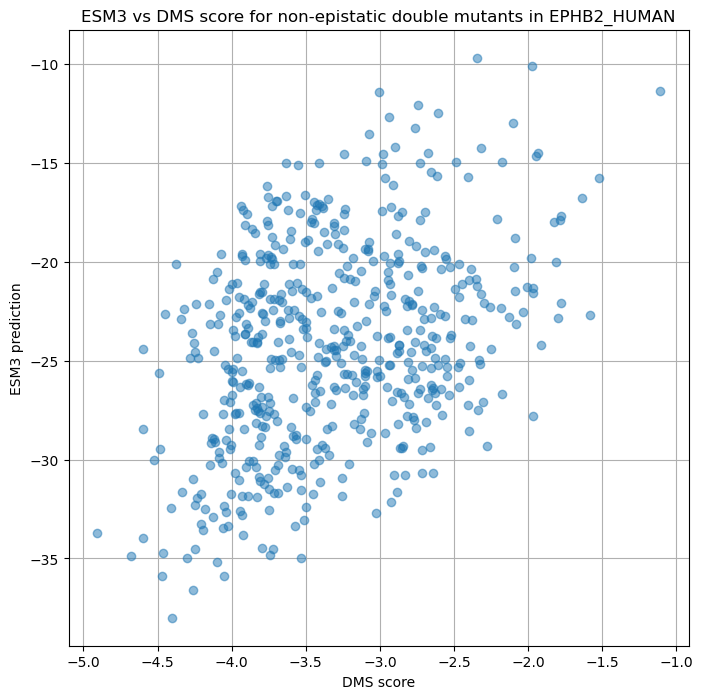

In [46]:
plt.figure(figsize=(8,8))
plt.plot(non_epistatic["DMS_score"], non_epistatic["ESM3"], 'o', alpha=0.5)
plt.xlabel("DMS score")
plt.ylabel("ESM3 prediction")
plt.title("ESM3 vs DMS score for non-epistatic double mutants in EPHB2_HUMAN")
plt.grid(True)
plt.show()

In [48]:
from scipy.stats import spearmanr

print(spearmanr(epistatic["DMS_score"], epistatic["ESM3"])[0])
print(spearmanr(non_epistatic["DMS_score"], non_epistatic["ESM3"])[0])

0.523731287055072
0.3299946358885412


In [7]:
list(epistatic.columns)[-20:]

['xTrimoPGLM-7B-CLM',
 'xTrimoPGLM-100B-int4',
 'Progen3_112m',
 'Progen3_219m',
 'Progen3_339m',
 'Progen3_762m',
 'Progen3_1b',
 'Progen3_3b',
 'num_mutations',
 'dG',
 'deltaG_95CI_low',
 'deltaG_95CI_high',
 'pair_name',
 'recon_dg',
 'thermodynamic_coupling',
 'epistatic',
 'symmetric_1',
 'symmetric_2',
 'symmetric_double',
 'dG_std']

In [8]:
epistatic[["mutant", "dG", "recon_dg", "DMS_score", "thermodynamic_coupling"]]

,mutant,dG,recon_dg,DMS_score,thermodynamic_coupling
Unnamed: 0,,,,,
248,F26A:M35A,0.666995,1.224994,-3.742021,-0.557999
252,F26A:M35F,3.765177,2.325021,-0.643839,1.440156
255,F26A:M35I,1.591587,1.841975,-2.817429,-0.250387
260,F26A:M35Q,0.684717,1.100342,-3.724299,-0.415626
262,F26A:M35S,0.542971,0.941778,-3.866045,-0.398807
...,...,...,...,...,...
1947,Y17W:H50I,2.008065,2.547872,-2.400951,-0.539807
1953,Y17W:H50Q,2.661765,1.989423,-1.747251,0.672342
1957,Y17W:H50V,1.812746,2.223460,-2.596270,-0.410714


In [54]:
epistatic["dG"]

Unnamed: 0
248     0.666995
252     3.765177
255     1.591587
260     0.684717
262     0.542971
          ...   
1947    2.008065
1953    2.661765
1957    1.812746
1958    2.331956
1959    1.955721
Name: dG, Length: 175, dtype: float64